# Layered Representations from a Single Image

### **Course Project:** Deep Learning for Computer Vision

### **Objective:**
**Convert one RGB image into an interpretable, re-composable stack of RGBA layers containing:**

- semantic/instance grouping
- relative depth ordering
- approximate albedo
- approximate shading
- editable layer outputs
- reconstructed image and depth-aware parallax demonstration

### **Used Pipeline**

`RGB image → Mask R-CNN instance segmentation → DPT monocular depth → depth ordering → RGBA layers → Retinex-inspired albedo/shading → recomposition/editing`

In [134]:
!pip -q install -U "transformers>=4.45,<6" timm scipy opencv-python-headless

In [135]:
# Imports and reproducibility
import os
import json
import math
import random
import shutil
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageEnhance
from scipy.ndimage import gaussian_filter
from IPython.display import display

import torch
import torch.nn.functional as F
import torchvision
from torchvision.transforms import functional as TF
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn,
    MaskRCNN_ResNet50_FPN_Weights
)

from transformers import DPTImageProcessor, DPTForDepthEstimation

warnings.filterwarnings("ignore")

In [136]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
Device: cpu


## 1. Project configuration

- `CONF_THRESHOLD`: For confidence threshold for Mask R-CNN.
- `MAX_OBJECTS`: To limits the number of retained objects so visualization and compositing remain manageable.
- `MASK_THRESHOLD`: Converts Mask R-CNN probability masks to binary masks.
- `DEPTH_MODEL_NAME`: Pretrained DPT model used for monocular relative depth.
- `INTRINSIC_SIGMA`: Gaussian scale used by the Retinex-inspired approximation.

In [137]:
# Configuration
CONF_THRESHOLD = 0.60
MASK_THRESHOLD = 0.50
MAX_OBJECTS = 12

DEPTH_MODEL_NAME = "Intel/dpt-hybrid-midas"
INTRINSIC_SIGMA = 15

OUTPUT_DIR = "/content/layered_output"
APPEARANCE_DIR = os.path.join(OUTPUT_DIR, "appearance")
os.makedirs(APPEARANCE_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /content/layered_output


## 2. Upload an input image

By this cell run we will upload a JPG/PNG image from computer.

**Note:**
1. This project notebook accepts any RGB scene. Photorealistic outdoor/indoor scenes with several recognizable objects. So upload such kind of image for project.
2. I have used

Saving corner_image.jpg to corner_image (1).jpg
Input: corner_image (1).jpg
Original size: (224, 224)


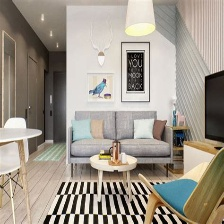

In [138]:
# Upload image
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No image was uploaded.")

image_path = next(iter(uploaded.keys()))
image = Image.open(image_path).convert("RGB")

print("Input:", image_path)
print("Original size:", image.size)

display(image)

In [139]:
# Prepare image
rgb_np = np.asarray(image).astype(np.float32) / 255.0
H, W = rgb_np.shape[:2]

print(f"Width={W}, Height={H}, Channels=3")
print("Tensor shape:", TF.to_tensor(image).shape)

Width=224, Height=224, Channels=3
Tensor shape: torch.Size([3, 224, 224])


## 3. Load pretrained Mask R-CNN

Mask R-CNN provides instance-level predictions:

$
(C_i, P_i, B_i, M_i)
$

where `C` is class, `P` is confidence, `B` is bounding box, and `M` is a pixel mask.

This is the semantic grouping stage of the project.

In [140]:
# Load Mask R-CNN
mask_weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT

mask_model = maskrcnn_resnet50_fpn(weights=mask_weights)
mask_model = mask_model.to(DEVICE)
mask_model.eval()

COCO_CATEGORIES = mask_weights.meta["categories"]

print("Mask R-CNN loaded.")
print("COCO categories:", len(COCO_CATEGORIES))

Mask R-CNN loaded.
COCO categories: 91


In [141]:
# 7 - Run instance segmentation
image_tensor = TF.to_tensor(image).to(DEVICE)

with torch.inference_mode():
    prediction = mask_model([image_tensor])[0]

raw_scores = prediction["scores"].detach().cpu().numpy()
raw_labels = prediction["labels"].detach().cpu().numpy()
raw_masks = prediction["masks"].detach().cpu().numpy()[:, 0]
raw_boxes = prediction["boxes"].detach().cpu().numpy()

keep = raw_scores >= CONF_THRESHOLD

scores = raw_scores[keep]
labels = raw_labels[keep]
masks_prob = raw_masks[keep]
boxes = raw_boxes[keep]

if len(scores) > MAX_OBJECTS:
    order = np.argsort(-scores)[:MAX_OBJECTS]
    scores = scores[order]
    labels = labels[order]
    masks_prob = masks_prob[order]
    boxes = boxes[order]

binary_masks = masks_prob >= MASK_THRESHOLD

print("Retained instances:", len(scores))

for i in range(len(scores)):
    print(
        f"{i:02d} | {COCO_CATEGORIES[labels[i]]:20s} | "
        f"confidence={scores[i]:.3f}"
    )

Retained instances: 9
00 | couch                | confidence=0.993
01 | chair                | confidence=0.990
02 | bird                 | confidence=0.976
03 | tv                   | confidence=0.959
04 | chair                | confidence=0.936
05 | dining table         | confidence=0.900
06 | bottle               | confidence=0.897
07 | dining table         | confidence=0.823
08 | dining table         | confidence=0.642


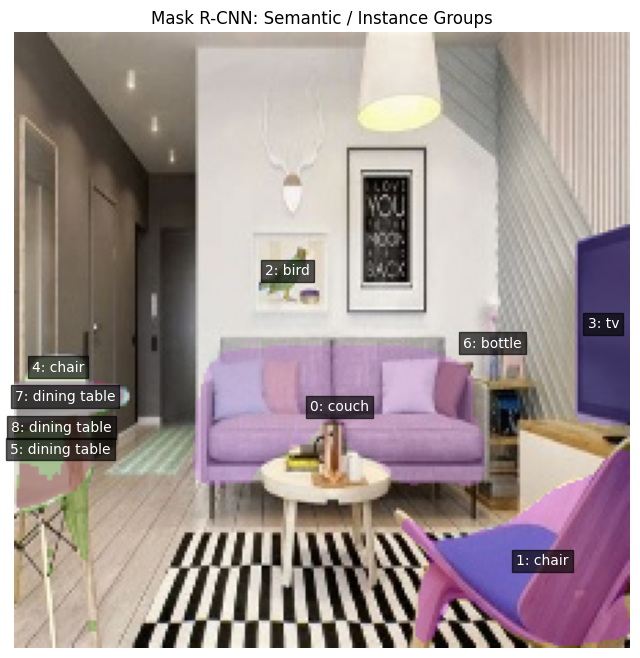

In [142]:
# 8 — Visualize semantic/instance segmentation
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image)

rng = np.random.default_rng(SEED)

for i, mask in enumerate(binary_masks):
    color = rng.random(3)

    overlay = np.zeros((H, W, 4), dtype=np.float32)
    overlay[..., :3] = color
    overlay[..., 3] = mask.astype(np.float32) * 0.35
    ax.imshow(overlay)

    ys, xs = np.where(mask)
    if len(xs):
        x, y = np.mean(xs), np.mean(ys)
        ax.text(
            x, y,
            f"{i}: {COCO_CATEGORIES[labels[i]]}",
            fontsize=10,
            color="white",
            ha="center",
            bbox=dict(facecolor="black", alpha=0.65, pad=3)
        )

ax.axis("off")
ax.set_title("Mask R-CNN: Semantic / Instance Groups")
plt.show()

## 4. Build the background layer

The background is initially defined as the complement of all retained foreground masks:

$
M_B = 1-\bigcup_i M_i
$

This is a practical baseline. It does not claim full "stuff" segmentation.

In [143]:
# 9 — Background mask
object_union = np.zeros((H, W), dtype=bool)

for mask in binary_masks:
    object_union |= mask

background_mask = ~object_union

print("Object coverage:     ", f"{100*object_union.mean():.2f}%")
print("Background coverage: ", f"{100*background_mask.mean():.2f}%")

Object coverage:      22.27%
Background coverage:  77.73%


## 5. Load DPT monocular depth estimation

DPT produces a dense depth prediction from a single image. We use the prediction only for **relative ordering**.

The model's processor handles the model-specific image preprocessing; the output is resized back to the original image dimensions.

In [144]:
# 10 — Load DPT depth model
depth_processor = DPTImageProcessor.from_pretrained(
    DEPTH_MODEL_NAME
)

depth_model = DPTForDepthEstimation.from_pretrained(
    DEPTH_MODEL_NAME
)

depth_model = depth_model.to(DEVICE)
depth_model.eval()

print("Depth model loaded:", DEPTH_MODEL_NAME)

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

Depth model loaded: Intel/dpt-hybrid-midas


In [145]:
# 11 — Predict monocular depth
depth_inputs = depth_processor(
    images=image,
    return_tensors="pt"
)

depth_inputs = {
    k: v.to(DEVICE)
    for k, v in depth_inputs.items()
}

with torch.inference_mode():
    depth_outputs = depth_model(**depth_inputs)

predicted_depth = depth_outputs.predicted_depth

depth_resized = F.interpolate(
    predicted_depth.unsqueeze(1),
    size=(H, W),
    mode="bicubic",
    align_corners=False
).squeeze()

depth_raw = depth_resized.detach().cpu().numpy()

# Robust normalization for visualization/relative ordering.
lo, hi = np.percentile(depth_raw, [1, 99])
depth_norm = np.clip((depth_raw - lo) / (hi - lo + 1e-8), 0, 1)

print("Depth shape:", depth_norm.shape)
print("Normalized range:", depth_norm.min(), depth_norm.max())

Depth shape: (224, 224)
Normalized range: 0.0 1.0


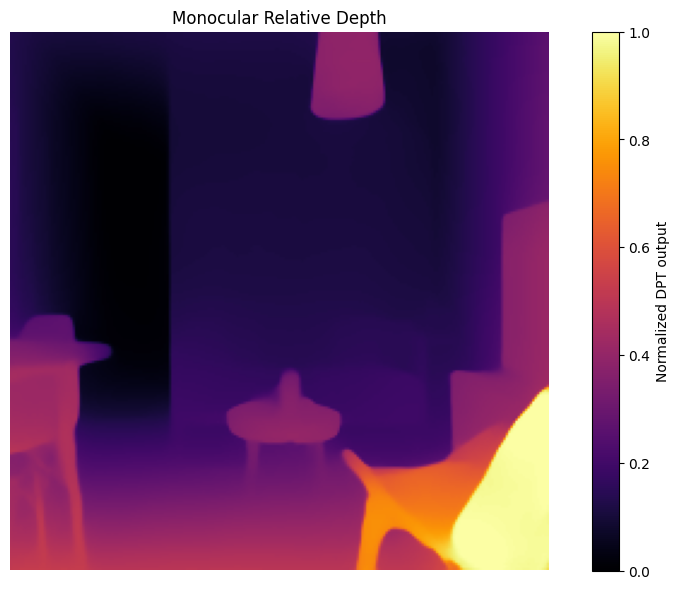

In [146]:
# 12 — Visualize depth
plt.figure(figsize=(11, 7))
plt.imshow(depth_norm, cmap="inferno")
plt.colorbar(label="Normalized DPT output")
plt.axis("off")
plt.title("Monocular Relative Depth")
plt.show()

### Depth convention check

Different monocular-depth checkpoints/documentation may use a prediction whose numerical direction is not the same as physical distance. We therefore estimate the ordering direction from the pretrained checkpoint using a simple image prior: the background complement is expected to be, on average, farther than foreground objects in ordinary scenes.

The project reports **relative depth order**, not metric distance.

If your test image violates that assumption, set `NEAR_IS_LOW` manually after inspecting the depth visualization.

In [147]:
# 13 — Determine/override depth direction
# DPT/MiDaS-style outputs commonly behave like inverse-depth:
# larger numerical values tend to correspond to nearer regions.
# therefore used "near = high" by default.
NEAR_IS_HIGH = True

print("Depth convention:", "near = HIGH" if NEAR_IS_HIGH else "near = LOW")

Depth convention: near = HIGH


In [148]:
# 14 — Calculate per-layer depth statistics
layer_records = []

for i, mask in enumerate(binary_masks):
    values = depth_norm[mask]

    if len(values) == 0:
        median_depth = float("nan")
        mean_depth = float("nan")
    else:
        median_depth = float(np.median(values))
        mean_depth = float(np.mean(values))

    layer_records.append({
        "original_index": i,
        "semantic_class": COCO_CATEGORIES[labels[i]],
        "confidence": float(scores[i]),
        "median_depth": median_depth,
        "mean_depth": mean_depth,
        "area_pixels": int(mask.sum()),
        "layer_type": "object"
    })

background_values = depth_norm[background_mask]

background_median = (
    float(np.median(background_values))
    if len(background_values) else float("nan")
)

background_mean = (
    float(np.mean(background_values))
    if len(background_values) else float("nan")
)

layer_records.append({
    "original_index": -1,
    "semantic_class": "background",
    "confidence": 1.0,
    "median_depth": background_median,
    "mean_depth": background_mean,
    "area_pixels": int(background_mask.sum()),
    "layer_type": "background"
})

stats_df = pd.DataFrame(layer_records)
stats_df

,original_index,semantic_class,confidence,median_depth,mean_depth,area_pixels,layer_type
0,0,couch,0.992629,0.153793,0.158664,4325,object
1,1,chair,0.989893,0.982177,0.843104,3507,object
2,2,bird,0.975950,0.112743,0.112600,132,object
3,3,tv,0.958587,0.383824,0.380891,1391,object
4,4,chair,0.935642,0.265963,0.257806,211,object
5,5,dining table,0.899893,0.426825,0.406383,1435,object
6,6,bottle,0.896763,0.124195,0.123018,104,object
7,7,dining table,0.822803,0.327927,0.319770,513,object
8,8,dining table,0.641894,0.422081,0.376983,946,object
9,-1,background,1.000000,0.117197,0.184345,39001,background


In [149]:
# 15 — Depth ordering
valid_depth = stats_df["median_depth"].fillna(
    stats_df["median_depth"].median()
)

if NEAR_IS_HIGH:
    order_indices = np.argsort(-valid_depth.to_numpy())
else:
    order_indices = np.argsort(valid_depth.to_numpy())

ordered_df = stats_df.iloc[order_indices].copy().reset_index(drop=True)
ordered_df.insert(0, "depth_rank_near_to_far", np.arange(1, len(ordered_df) + 1))

print("Near → far ordering:")
display(ordered_df)

Near → far ordering:


,depth_rank_near_to_far,original_index,semantic_class,confidence,median_depth,mean_depth,area_pixels,layer_type
0,1,1,chair,0.989893,0.982177,0.843104,3507,object
1,2,5,dining table,0.899893,0.426825,0.406383,1435,object
2,3,8,dining table,0.641894,0.422081,0.376983,946,object
3,4,3,tv,0.958587,0.383824,0.380891,1391,object
4,5,7,dining table,0.822803,0.327927,0.319770,513,object
5,6,4,chair,0.935642,0.265963,0.257806,211,object
6,7,0,couch,0.992629,0.153793,0.158664,4325,object
7,8,6,bottle,0.896763,0.124195,0.123018,104,object
8,9,-1,background,1.000000,0.117197,0.184345,39001,background
9,10,2,bird,0.975950,0.112743,0.112600,132,object


## 6. Intrinsic appearance approximation

We use the simplified image-formation model:

$
I \approx A\odot S
$

and a Retinex-inspired log-domain decomposition:

$
\log S \approx G_\sigma * \log I
$

$
A \approx \frac{I}{S+\epsilon}
$

This is intentionally labelled **approximate intrinsic decomposition**, because albedo and illumination cannot be uniquely recovered from a single RGB image without additional assumptions.

In [150]:
# 16 — Retinex-inspired albedo/shading
rgb = np.clip(rgb_np, 1e-4, 1.0)

gray = (
    0.299 * rgb[..., 0] +
    0.587 * rgb[..., 1] +
    0.114 * rgb[..., 2]
)

log_gray = np.log(gray + 1e-4)

log_shading = gaussian_filter(
    log_gray,
    sigma=INTRINSIC_SIGMA
)

shading = np.exp(log_shading)

# Normalize shading for a stable visualization.
shading = shading / (np.percentile(shading, 99) + 1e-8)
shading = np.clip(shading, 0.05, 1.5)

albedo = rgb / shading[..., None]
albedo = np.clip(albedo, 0, 1)

print("Albedo:", albedo.shape)
print("Shading:", shading.shape)

Albedo: (224, 224, 3)
Shading: (224, 224)


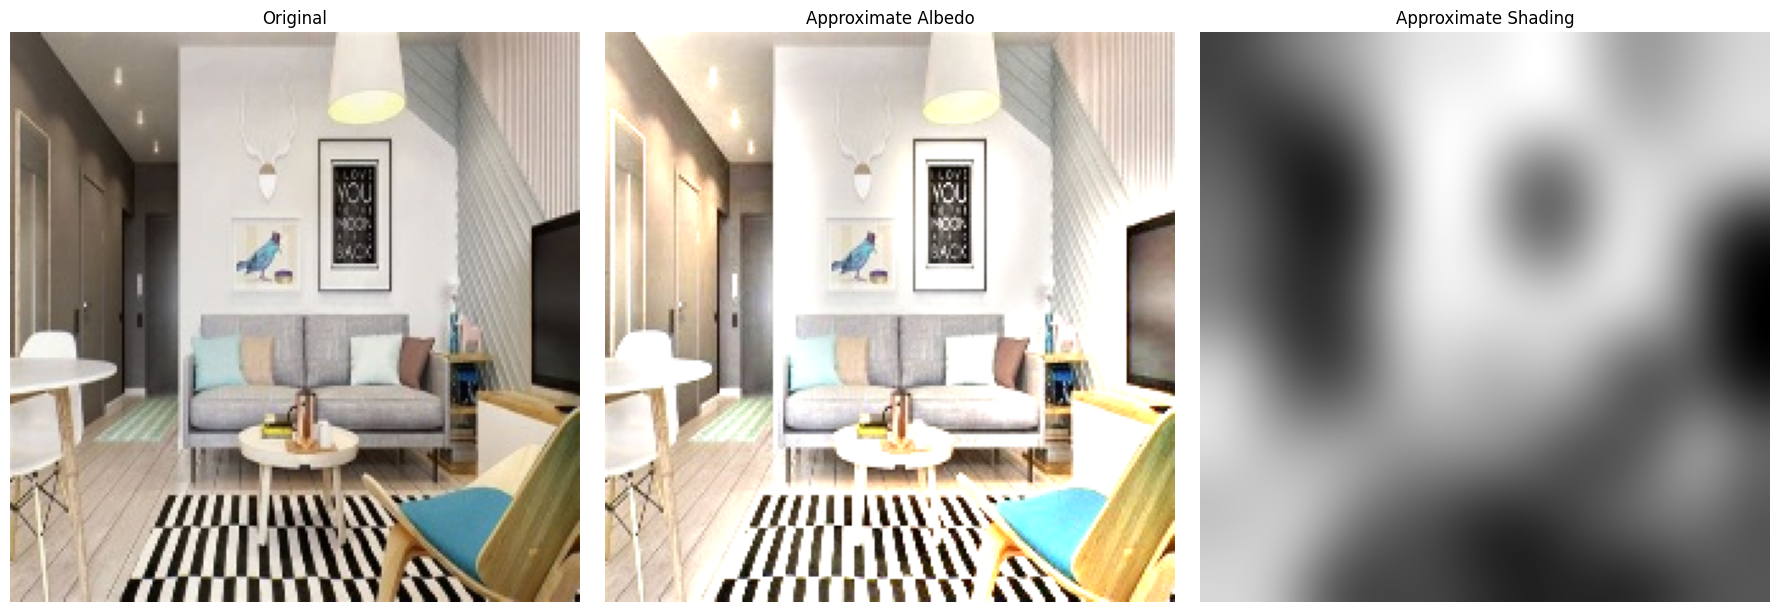

In [151]:
# 17 — Visualize albedo and shading
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original")

axes[1].imshow(albedo)
axes[1].set_title("Approximate Albedo")

axes[2].imshow(shading, cmap="gray")
axes[2].set_title("Approximate Shading")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Create RGBA layers

Each layer is stored as:

$
L_i=[R_i,G_i,B_i,\alpha_i]
$

with alpha equal to 255 inside the layer mask and 0 elsewhere.

We preserve the original RGB values and use the segmentation mask as transparency.

In [152]:
# 18 — Create RGBA object/background layers
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(APPEARANCE_DIR, exist_ok=True)

original_rgb_uint8 = np.asarray(image).astype(np.uint8)

saved_layer_records = []

def safe_filename(text):
    return "".join(
        c if c.isalnum() or c in "-_"
        else "_"
        for c in text
    )

# Object layers
for i, mask in enumerate(binary_masks):
    class_name = COCO_CATEGORIES[labels[i]]
    safe_name = safe_filename(class_name)

    rgba = np.zeros((H, W, 4), dtype=np.uint8)
    rgba[..., :3] = original_rgb_uint8
    rgba[..., 3] = mask.astype(np.uint8) * 255

    path = os.path.join(
        OUTPUT_DIR,
        f"layer_{i+1:02d}_{safe_name}.png"
    )

    Image.fromarray(rgba, "RGBA").save(path)

    saved_layer_records.append({
        "original_index": i,
        "semantic_class": class_name,
        "file": path
    })

# Background layer
background_rgba = np.zeros((H, W, 4), dtype=np.uint8)
background_rgba[..., :3] = original_rgb_uint8
background_rgba[..., 3] = background_mask.astype(np.uint8) * 255

background_path = os.path.join(
    OUTPUT_DIR,
    "layer_background.png"
)

Image.fromarray(
    background_rgba, "RGBA"
).save(background_path)

saved_layer_records.append({
    "original_index": -1,
    "semantic_class": "background",
    "file": background_path
})

print("Saved", len(saved_layer_records), "RGBA layers.")

Saved 10 RGBA layers.


In [153]:
# 19 — Save per-layer albedo and shading
for i, mask in enumerate(binary_masks):
    class_name = safe_filename(COCO_CATEGORIES[labels[i]])

    # Albedo
    albedo_layer = albedo * mask[..., None]
    albedo_uint8 = np.clip(albedo_layer * 255, 0, 255).astype(np.uint8)

    albedo_path = os.path.join(
        APPEARANCE_DIR,
        f"layer_{i+1:02d}_{class_name}_albedo.png"
    )
    Image.fromarray(albedo_uint8, "RGB").save(albedo_path)

    # Shading
    shading_vis = np.clip(shading, 0, 1) * mask
    shading_uint8 = np.clip(shading_vis * 255, 0, 255).astype(np.uint8)

    shading_path = os.path.join(
        APPEARANCE_DIR,
        f"layer_{i+1:02d}_{class_name}_shading.png"
    )
    Image.fromarray(shading_uint8, "L").save(shading_path)

print("Saved albedo/shading maps.")

Saved albedo/shading maps.


In [154]:
# 20 — Build final metadata table

final_rows = []

for rank, row in ordered_df.iterrows():
    original_index = int(row["original_index"])

    matching = [
        x for x in saved_layer_records
        if x["original_index"] == original_index
    ]

    file_path = matching[0]["file"] if matching else None

    final_rows.append({
        "depth_rank_near_to_far": int(row["depth_rank_near_to_far"]),
        "semantic_class": row["semantic_class"],
        "layer_type": row["layer_type"],
        "confidence": float(row["confidence"]),
        "median_depth": float(row["median_depth"]),
        "mean_depth": float(row["mean_depth"]),
        "area_pixels": int(row["area_pixels"]),
        "rgba_file": file_path
    })

final_df = pd.DataFrame(final_rows)

csv_path = os.path.join(
    OUTPUT_DIR,
    "layer_metadata.csv"
)

final_df.to_csv(csv_path, index=False)

metadata = {
    "project": "Layered Representations from a Single Image",
    "input_image": image_path,
    "image_width": W,
    "image_height": H,
    "segmentation_model": "Mask R-CNN ResNet-50 FPN",
    "depth_model": DEPTH_MODEL_NAME,
    "confidence_threshold": CONF_THRESHOLD,
    "mask_threshold": MASK_THRESHOLD,
    "intrinsic_method": "Retinex-inspired log-domain approximation",
    "intrinsic_sigma": INTRINSIC_SIGMA,
    "depth_order": "near-to-far relative ordering",
    "near_is_high": NEAR_IS_HIGH,
    "num_object_layers": len(binary_masks),
    "num_total_layers": len(binary_masks) + 1
}

json_path = os.path.join(
    OUTPUT_DIR,
    "metadata.json"
)

with open(json_path, "w") as f:
    json.dump(metadata, f, indent=2)

display(final_df)

,depth_rank_near_to_far,semantic_class,layer_type,confidence,median_depth,mean_depth,area_pixels,rgba_file
0,1,chair,object,0.989893,0.982177,0.843104,3507,/content/layered_output/layer_02_chair.png
1,2,dining table,object,0.899893,0.426825,0.406383,1435,/content/layered_output/layer_06_dining_table.png
2,3,dining table,object,0.641894,0.422081,0.376983,946,/content/layered_output/layer_09_dining_table.png
3,4,tv,object,0.958587,0.383824,0.380891,1391,/content/layered_output/layer_04_tv.png
4,5,dining table,object,0.822803,0.327927,0.319770,513,/content/layered_output/layer_08_dining_table.png
5,6,chair,object,0.935642,0.265963,0.257806,211,/content/layered_output/layer_05_chair.png
6,7,couch,object,0.992629,0.153793,0.158664,4325,/content/layered_output/layer_01_couch.png
7,8,bottle,object,0.896763,0.124195,0.123018,104,/content/layered_output/layer_07_bottle.png
8,9,background,background,1.000000,0.117197,0.184345,39001,/content/layered_output/layer_background.png
9,10,bird,object,0.975950,0.112743,0.112600,132,/content/layered_output/layer_03_bird.png


## 8. Visualize every RGBA layer

The checkerboard/black background is only a display aid. The actual PNG files retain an alpha channel.

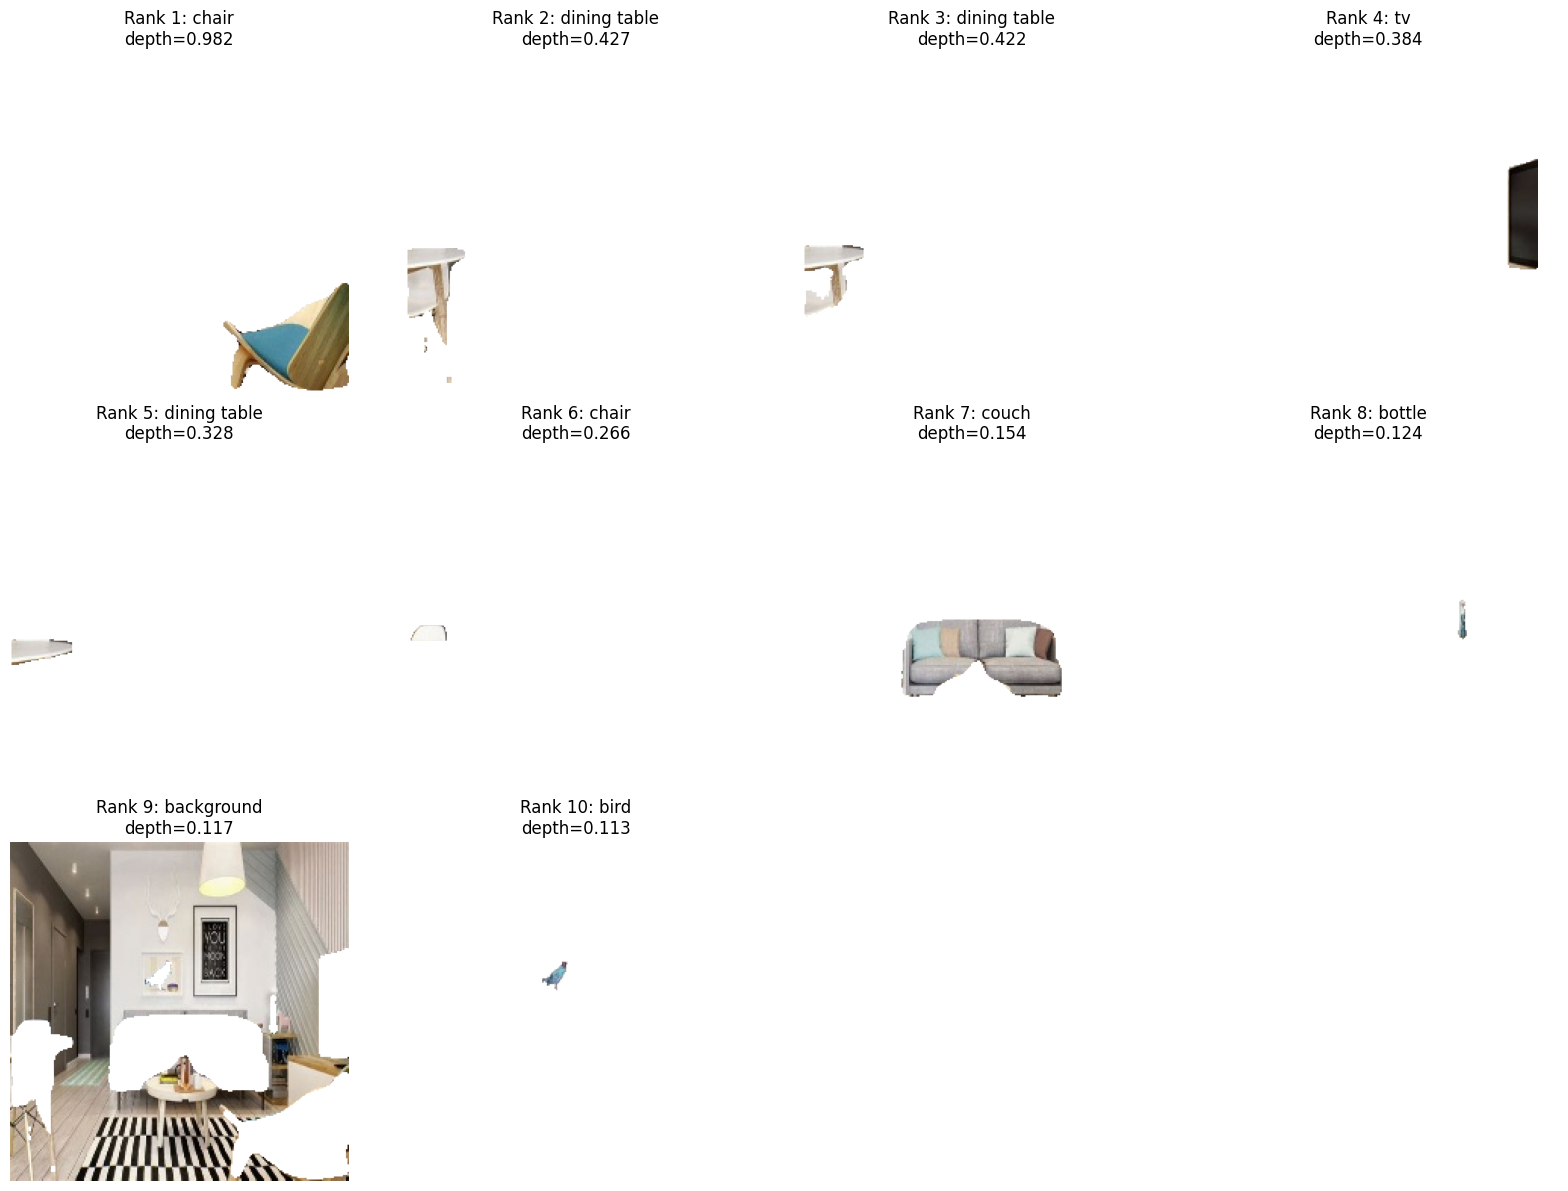

In [155]:
# 21 — Display ordered RGBA layers

n_layers = len(final_df)
ncols = min(4, max(1, n_layers))
nrows = math.ceil(n_layers / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4*ncols, 4*nrows),
    squeeze=False
)

for ax in axes.ravel():
    ax.axis("off")

for ax, (_, row) in zip(axes.ravel(), final_df.iterrows()):
    rgba_img = Image.open(row["rgba_file"]).convert("RGBA")
    ax.imshow(rgba_img)
    ax.set_title(
        f"Rank {int(row['depth_rank_near_to_far'])}: "
        f"{row['semantic_class']}\n"
        f"depth={row['median_depth']:.3f}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 9. Re-compose the scene from the RGBA layers

Alpha compositing uses:

$
C_{out}=\alpha_f C_f+(1-\alpha_f)C_b
$

The reconstruction test checks whether the layer representation preserves the original image.

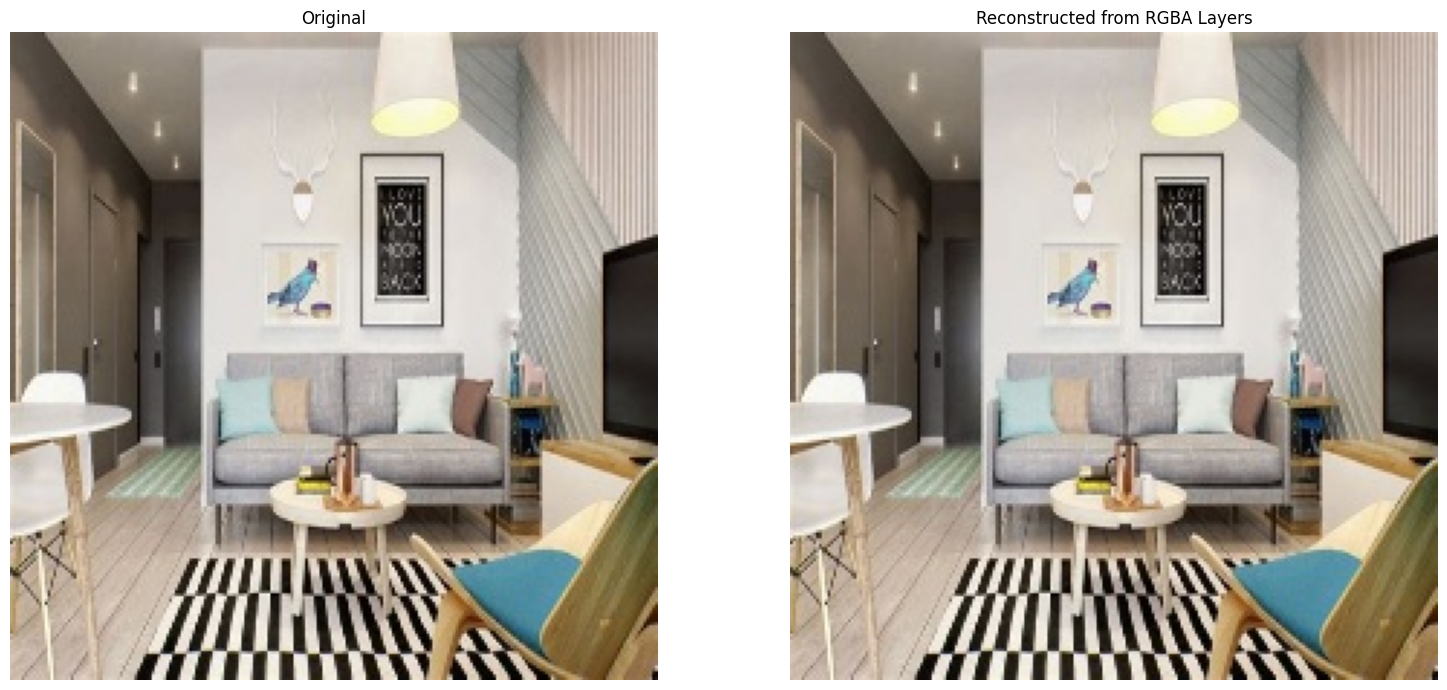

In [156]:
# 22 — Alpha compositing

def alpha_composite_layers(paths):
    result = Image.new("RGBA", (W, H), (0, 0, 0, 0))

    # For normal compositing, far layers are placed first.
    for path in reversed(paths):
        layer = Image.open(path).convert("RGBA")
        result = Image.alpha_composite(result, layer)

    return result

ordered_paths = final_df["rgba_file"].tolist()

reconstructed = alpha_composite_layers(ordered_paths)
reconstructed_rgb = reconstructed.convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(image)
axes[0].set_title("Original")

axes[1].imshow(reconstructed_rgb)
axes[1].set_title("Reconstructed from RGBA Layers")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [157]:
# 23 — Reconstruction metrics

original_arr = np.asarray(image).astype(np.float32) / 255.0
reconstructed_arr = np.asarray(reconstructed_rgb).astype(np.float32) / 255.0

mae = float(np.mean(np.abs(original_arr - reconstructed_arr)))
mse = float(np.mean((original_arr - reconstructed_arr) ** 2))

psnr = float("inf") if mse == 0 else float(
    10 * np.log10(1.0 / mse)
)

print(f"MAE  : {mae:.8f}")
print(f"MSE  : {mse:.8f}")
print(f"PSNR : {psnr:.3f} dB")

MAE  : 0.00000000
MSE  : 0.00000000
PSNR : inf dB


## 10. Layer editing — remove an object

Because each object is stored independently, object removal becomes a layer operation rather than a full-image regeneration problem.

The result may contain holes/occluded regions; this baseline does not perform generative inpainting.

Removed: chair


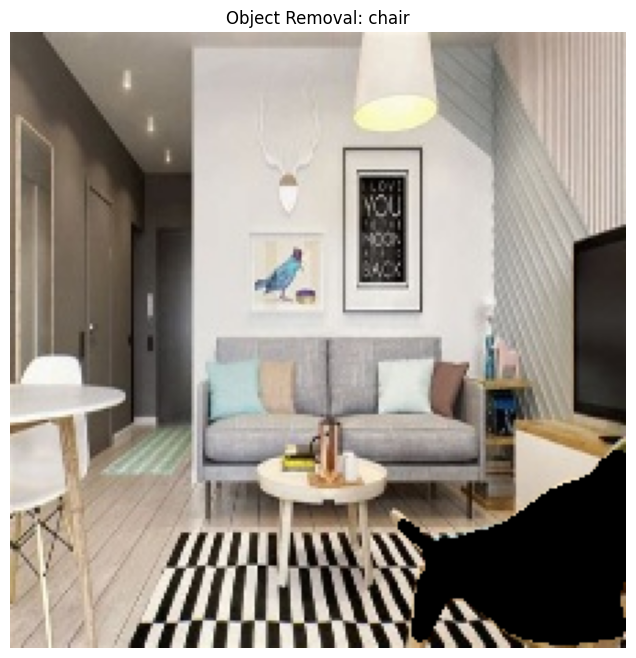

In [158]:
# 24 — Remove a selected layer

if len(final_df) > 1:
    # Select the nearest non-background layer.
    removable = final_df[
        final_df["semantic_class"] != "background"
    ]

    if len(removable):
        selected = removable.iloc[0]
        selected_path = selected["rgba_file"]

        remaining_paths = [
            p for p in ordered_paths
            if p != selected_path
        ]

        removed_result = alpha_composite_layers(remaining_paths)

        print("Removed:", selected["semantic_class"])

        plt.figure(figsize=(12, 8))
        plt.imshow(removed_result.convert("RGB"))
        plt.axis("off")
        plt.title(f"Object Removal: {selected['semantic_class']}")
        plt.show()
else:
    print("No removable object layer was detected.")

## 11. Layer appearance editing

This example increases brightness of one object layer. The edit is applied only to the selected RGBA layer.

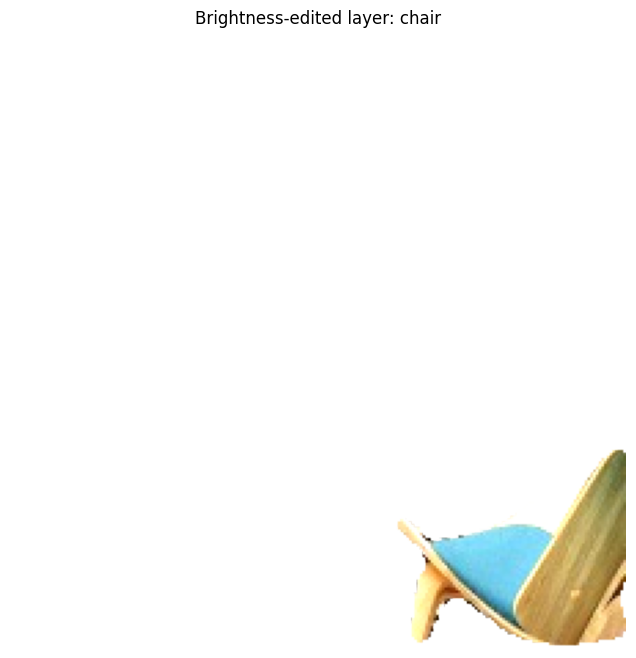

In [159]:
# 25 — Brightness edit

def change_layer_brightness(rgba_image, factor=1.35):
    arr = np.asarray(rgba_image.convert("RGBA")).copy()

    rgb = arr[..., :3].astype(np.float32)
    alpha = arr[..., 3]

    rgb = np.clip(rgb * factor, 0, 255)

    out = np.dstack([
        rgb.astype(np.uint8),
        alpha
    ])

    return Image.fromarray(out, "RGBA")

object_rows = final_df[
    final_df["semantic_class"] != "background"
]

if len(object_rows):
    selected = object_rows.iloc[0]

    edited = change_layer_brightness(
        Image.open(selected["rgba_file"]),
        factor=1.50
    )

    plt.figure(figsize=(12, 8))
    plt.imshow(edited)
    plt.axis("off")
    plt.title(
        f"Brightness-edited layer: "
        f"{selected['semantic_class']}"
    )
    plt.show()
else:
    print("No object layer available for editing.")

## 12. Depth-aware parallax demonstration

A simple 2-D approximation is used:

- nearer layers receive larger horizontal displacement
- farther layers receive smaller displacement

This is not full 3-D rendering, but it demonstrates why depth ordering makes a layered representation useful for animation/parallax.

In [160]:

# 26 — RGBA translation helper

def shift_rgba(img, dx):
    arr = np.asarray(img.convert("RGBA"))
    shifted = np.zeros_like(arr)

    if dx == 0:
        return img.copy()

    if dx > 0:
        shifted[:, dx:] = arr[:, :-dx]
    else:
        shifted[:, :dx] = arr[:, -dx:]

    return Image.fromarray(shifted, "RGBA")

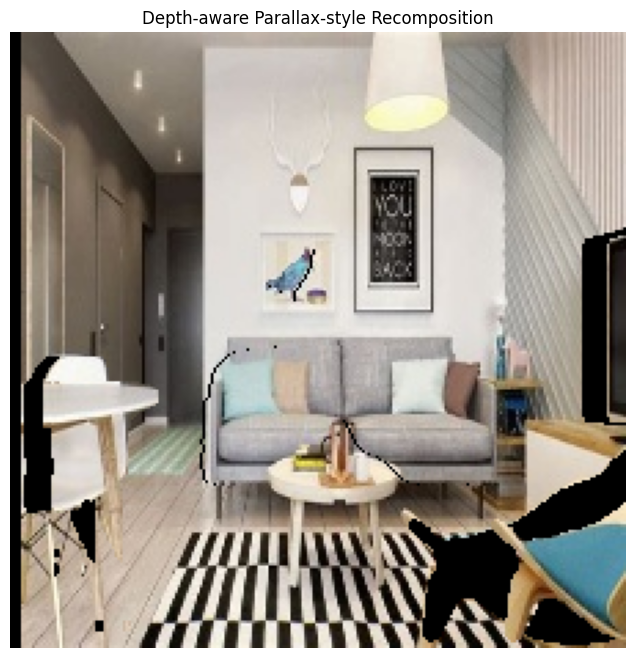

In [161]:

# 27 — Create parallax-style recomposition

parallax = Image.new(
    "RGBA",
    (W, H),
    (0, 0, 0, 0)
)

# Far-to-near compositing.
for _, row in final_df.iloc[::-1].iterrows():

    layer = Image.open(row["rgba_file"]).convert("RGBA")

    depth_value = float(row["median_depth"])

    if NEAR_IS_HIGH:
        near_amount = depth_value
    else:
        near_amount = 1.0 - depth_value

    displacement = int(np.clip(near_amount * 35, -35, 35))

    shifted = shift_rgba(layer, displacement)

    parallax = Image.alpha_composite(
        parallax,
        shifted
    )

plt.figure(figsize=(12, 8))
plt.imshow(parallax.convert("RGB"))
plt.axis("off")
plt.title("Depth-aware Parallax-style Recomposition")
plt.show()

## 13. Quantitative summary

The following table is useful in the project report.

In [162]:

# 28 — DL4CV_Project summary

summary = pd.DataFrame([{
    "input_image": os.path.basename(image_path),
    "width": W,
    "height": H,
    "objects_detected": len(binary_masks),
    "total_layers": len(final_df),
    "mean_detection_confidence": (
        float(np.mean(scores)) if len(scores) else 0.0
    ),
    "reconstruction_MAE": mae,
    "reconstruction_MSE": mse,
    "reconstruction_PSNR_dB": psnr
}])

display(summary)
summary.to_csv(
    os.path.join(OUTPUT_DIR, "DL4CV_project_summary.csv"),
    index=False
)

,input_image,width,height,objects_detected,total_layers,mean_detection_confidence,reconstruction_MAE,reconstruction_MSE,reconstruction_PSNR_dB
0,corner_image (1).jpg,224,224,9,10,0.901562,0.0,0.0,inf


## 14. Save important visualization figures

These figures can be directly inserted into the final project report.

In [163]:

# 29 — Save report figures

FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Original
plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "01_original.png"),
    dpi=180,
    bbox_inches="tight"
)
plt.close()

# Depth
plt.figure(figsize=(10, 7))
plt.imshow(depth_norm, cmap="inferno")
plt.axis("off")
plt.colorbar()
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "02_depth.png"),
    dpi=180,
    bbox_inches="tight"
)
plt.close()

# Albedo
plt.figure(figsize=(10, 7))
plt.imshow(albedo)
plt.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "03_albedo.png"),
    dpi=180,
    bbox_inches="tight"
)
plt.close()

# Shading
plt.figure(figsize=(10, 7))
plt.imshow(shading, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "04_shading.png"),
    dpi=180,
    bbox_inches="tight"
)
plt.close()

# Reconstruction
plt.figure(figsize=(10, 7))
plt.imshow(reconstructed_rgb)
plt.axis("off")
plt.tight_layout()
plt.savefig(
    os.path.join(FIG_DIR, "05_reconstruction.png"),
    dpi=180,
    bbox_inches="tight"
)
plt.close()

print("Saved figures to:", FIG_DIR)

Saved figures to: /content/layered_output/figures


## 15. Create a ZIP containing all project outputs

The ZIP contains:

- RGBA layers
- albedo maps
- shading maps
- metadata
- CSV results
- report figures

In [164]:

# 30 — Package outputs

zip_path = "/content/layered_representation_project_output.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for root, _, filenames in os.walk(OUTPUT_DIR):
        for filename in filenames:
            path = os.path.join(root, filename)
            arcname = os.path.relpath(path, OUTPUT_DIR)
            zf.write(path, arcname)

print("Created:", zip_path)
print("Size:", os.path.getsize(zip_path) / (1024**2), "MB")

Created: /content/layered_representation_project_output.zip
Size: 73.09316539764404 MB


# 16. Final project interpretation

The notebook has transformed:

$
I\in\mathbb{R}^{H\times W\times3}
$

into:

$
\mathcal{L}=\{L_1,L_2,\ldots,L_N,L_B\}
$

where each layer has:

- semantic class
- pixel mask / alpha
- relative depth
- RGB appearance
- approximate albedo
- approximate shading

The representation can therefore support:

1. semantic inspection
2. depth ordering
3. object removal
4. layer-specific appearance editing
5. recomposition
6. simple parallax animation

### Limitations to state in the report

- Mask R-CNN may miss objects or produce imperfect boundaries.
- The background is the complement of detected object masks.
- Monocular depth is relative and may fail on unusual scenes.
- Single-image intrinsic decomposition is ambiguous.
- Object removal is not accompanied by generative inpainting.
- Parallax is a 2-D approximation, not full 3-D reconstruction.

### Conclusion

The main contribution is the **integration of semantic segmentation, monocular depth and approximate intrinsic appearance into an editable RGBA layer representation**, rather than training a new large model from scratch.

In [165]:

# 31 — download final ZIP

from google.colab import files
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>